In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, kruskal, mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd

[Swap(2), Reversion(2), Insertion(2), Slide(2)]

[ETN(2), RS(2), SPS(2), SRPS(2)]

[Swap(2), Reversion(2), ETN(2), RS(2)]

## Size 100

In [2]:
filename = './tests/run_parallel/results/script_100_fx_values.npz'
data = np.load(filename)
data = data["fx_array"]

# Take the first 30 elements (from index 0 to 29)
op_1 = data[:30]

# Take elements from index 30 to 59
op_2 = data[30:60]

# Take elements from index 60 to 89
op_3 = data[60:90]

ops = [op_1, op_2, op_3]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20572\4181273408.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ops, labels=['1', '2', '3'])


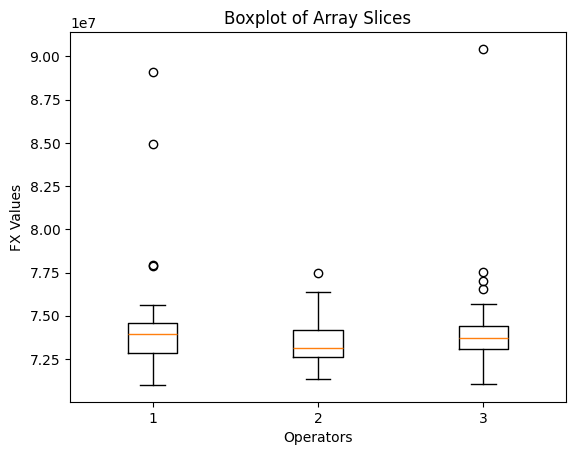

In [3]:
plt.boxplot(ops, labels=['1', '2', '3'])
plt.title('Boxplot of Array Slices')
plt.xlabel('Operators')
plt.ylabel('FX Values')
plt.show()

In [4]:
print(shapiro(op_1))
print(shapiro(op_2))
print(shapiro(op_3))

ShapiroResult(statistic=0.6681418624175701, pvalue=5.540066002878819e-07)
ShapiroResult(statistic=0.9349730878677687, pvalue=0.06664728562345654)
ShapiroResult(statistic=0.5917254184890528, pvalue=5.7928891765156324e-08)


op_2 can be considered normally distributed, while op_1 and op_3 cannot.

In [5]:
# perform Kruskal-Wallis test
# H0: the medians of the groups are equal

# does not assume normality

print(kruskal(op_1, op_2, op_3))

KruskalResult(statistic=3.115897435897409, pvalue=0.21056756195526788)


since H0 is not rejected, the medians are equal.

## Size 200

In [6]:
filename = './tests/run_parallel/results/script_200_fx_values.npz'
data = np.load(filename)
data = data["fx_array"]

op_1 = data[:30]
op_2 = data[30:60]
op_3 = data[60:90]
ops = [op_1, op_2, op_3]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20572\4181273408.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ops, labels=['1', '2', '3'])


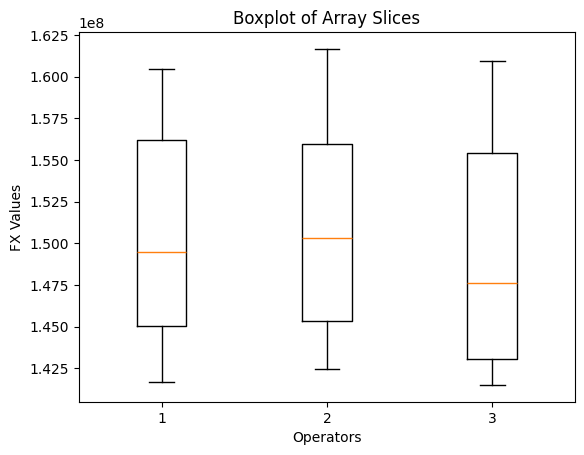

In [7]:
plt.boxplot(ops, labels=['1', '2', '3'])
plt.title('Boxplot of Array Slices')
plt.xlabel('Operators')
plt.ylabel('FX Values')
plt.show()

In [8]:
print(shapiro(op_1))
print(shapiro(op_2))
print(shapiro(op_3))

ShapiroResult(statistic=0.9188078929760816, pvalue=0.024980185972279502)
ShapiroResult(statistic=0.930950265232684, pvalue=0.05204378082887471)
ShapiroResult(statistic=0.8837971077088668, pvalue=0.0034501362290982)


They are not normally distributed.

In [9]:
print(kruskal(op_1, op_2, op_3))

KruskalResult(statistic=2.189304029304026, pvalue=0.33465604208783317)


There is evidence that at least one of the groups (op_1, op_2, or op_3) has a different median.

In [10]:
# Mann-Whitney U test for each pair of groups
u_stat1, p_value1 = mannwhitneyu(op_1, op_2)
u_stat2, p_value2 = mannwhitneyu(op_1, op_3)
u_stat3, p_value3 = mannwhitneyu(op_2, op_3)

print(f"op_1 vs op_2: U={u_stat1}, p={p_value1}")
print(f"op_1 vs op_3: U={u_stat2}, p={p_value2}")
print(f"op_2 vs op_3: U={u_stat3}, p={p_value3}")

op_1 vs op_2: U=462.0, p=0.8649937061644875
op_1 vs op_3: U=539.0, p=0.19073033347156776
op_2 vs op_3: U=533.0, p=0.22257289646656508


op_3 tends to have greater values than op_2

## Size 400

In [11]:
filename = './tests/run_parallel/results/script_400_fx_values.npz'
data = np.load(filename)
data = data["fx_array"]

op_1 = data[:30]
op_2 = data[30:60]
op_3 = data[60:90]
ops = [op_1, op_2, op_3]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20572\4181273408.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ops, labels=['1', '2', '3'])


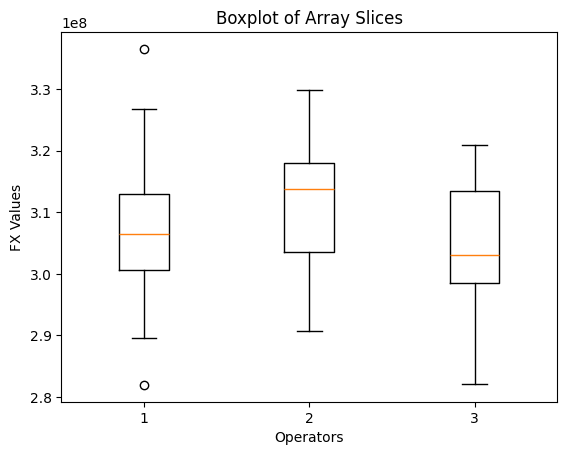

In [12]:
plt.boxplot(ops, labels=['1', '2', '3'])
plt.title('Boxplot of Array Slices')
plt.xlabel('Operators')
plt.ylabel('FX Values')
plt.show()

In [13]:
print(shapiro(op_1))
print(shapiro(op_2))
print(shapiro(op_3))

ShapiroResult(statistic=0.9780785000471904, pvalue=0.7724858457727906)
ShapiroResult(statistic=0.9439870374914812, pvalue=0.11649431490684459)
ShapiroResult(statistic=0.9593062030797413, pvalue=0.29734723592958334)


The three of them are normally distributed.

In [18]:
f_value, p_value = stats.f_oneway(op_1, op_2, op_3)

print(f"P-value: {p_value}")

P-value: 0.1182067957498941


There is no statistical difference between the medians.

## Size 800

In [ ]:
filename = './tests/run_parallel/results/script_800_fx_values.npz'
data = np.load(filename)
data = data["fx_array"]

op_1 = data[:30]
op_2 = data[30:60]
op_3 = data[60:90]
ops = [op_1, op_2, op_3]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13432\4181273408.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ops, labels=['1', '2', '3'])


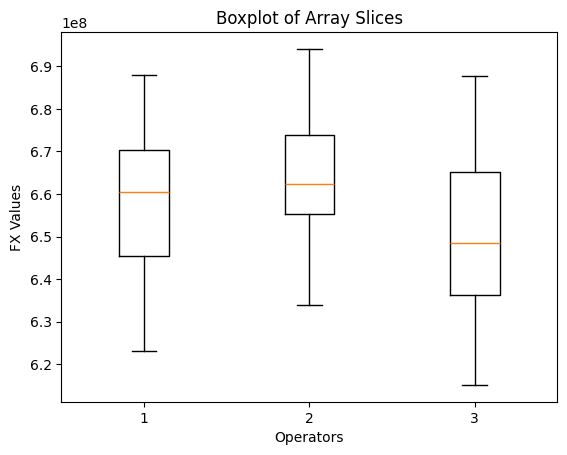

In [ ]:
plt.boxplot(ops, labels=['1', '2', '3'])
plt.title('Boxplot of Array Slices')
plt.xlabel('Operators')
plt.ylabel('FX Values')
plt.show()

In [ ]:
print(shapiro(op_1))
print(shapiro(op_2))
print(shapiro(op_3))

ShapiroResult(statistic=0.9667474640749761, pvalue=0.45442794540518117)
ShapiroResult(statistic=0.9744335787833083, pvalue=0.6660454221925945)
ShapiroResult(statistic=0.9786336962553754, pvalue=0.7881738736962429)


The three of them are normally distributed.

In [19]:
f_value, p_value = stats.f_oneway(op_1, op_2, op_3)

print(f"P-value: {p_value}")

P-value: 0.1182067957498941


There is no statistical difference between the medians.

## Size 1600